# Prueba F - Scooters trips

## Objetivo

Se construye una prueba end-to-end sobre trayectorias de scooters que ya vienen como viajes resumidos con geometría `LineString`. El objetivo es mostrar que el módulo también puede absorber una fuente que no parte como tabla OD plana, pero que sí trae trayectorias completas suficientes para aplanarse a una representación tabular de viajes.

Esta prueba busca mostrar que el módulo puede:

1. integrar una fuente GeoJSON de trayectorias,
2. transformar cada trayectoria a un viaje OD tabular,
3. validar y limpiar el dataset resultante,
4. derivar flows persistibles y visualizables,
5. y comparar un baseline general con dos contrastes analíticos simples:
   - viajes de marzo de 2019,
   - viajes de tarde entre 18:00 y 22:59.

En esta prueba el análisis es **no ponderado**. Por ello, los flows deben interpretarse como conteos observados de viajes de scooters, no como estimaciones expandidas a población.

## Contexto y preprocess integrado

La lógica general del preprocess es la siguiente:

- cargar un `FeatureCollection` GeoJSON;
- interpretar cada `Feature` como una trayectoria ya existente;
- extraer el primer punto del `LineString` como origen;
- extraer el último punto como destino;
- tomar `departure_time` como tiempo de inicio;
- construir `destination_time` sumando `travel_time_minutes`;
- renombrar `vehicle_id` como `user_id`;
- conservar atributos descriptivos del desplazamiento;
- y dejar como resultado final el dataframe `trips_df`, que será la entrada al bloque de trips del módulo.

La fuente no se presenta aquí como puntos ni como inferencia de trayectorias nuevas. Lo que existe inicialmente es una colección de trayectorias ya reportadas, que se aplanan a una tabla OD usando extremos espaciales y duración reportada.

In [1]:
from pathlib import Path
import sys

import pandas as pd
import geopandas as gpd
from IPython.display import display

REPO_ROOT = Path("../..").resolve()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

ARTIFACTS_ROOT = REPO_ROOT / "data" / "flows" / "demo_8_scooters_trips"
ARTIFACTS_ROOT.mkdir(parents=True, exist_ok=True)

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 220)
pd.set_option("display.max_colwidth", 140)

from pylondrina.importing import import_trips_from_dataframe, ImportOptions
from pylondrina.validation import validate_trips, ValidationOptions
from pylondrina.transforms.cleaning import clean_trips, CleanOptions
from pylondrina.transforms.filtering import filter_trips, FilterOptions, TimeFilter
from pylondrina.transforms.flows import build_flows, FlowBuildOptions
from pylondrina.io.flows import write_flows, WriteFlowsOptions
from pylondrina.schema import TripSchema, FieldSpec, DomainSpec

## Carga del GeoJSON crudo

Se parte del archivo GeoJSON de trayectorias. Cada `Feature` representa un desplazamiento ya resumido espacialmente como un `LineString`, por lo que el preprocess consiste en aplanar esa trayectoria a una fila OD.

In [3]:
RAW_GEOJSON_PATH =  REPO_ROOT / "data" / "scooters" / "cleaned_trips.geo.json"
gdf = gpd.read_file(RAW_GEOJSON_PATH).copy()

display(gdf.head())
print("Shape raw GeoJSON:", gdf.shape)
print("Geometry types:", gdf.geometry.geom_type.value_counts(dropna=False).to_dict())

,vehicle_id,delta_dist,distance_covered,average_speed,travel_time_minutes,departure_period,coverage_period,weekday,departure_time,hour,origin_zone,destination_zone,geometry
0,15,1.290820,1.290820,7.899219,10,afternoon_peak,3,6,2019-03-17 19:44:09.196,19.733333,498,287,"LINESTRING (-70.60534 -33.41777, -70.60534 -33.41777, -70.60534 -33.41777, -70.60536 -33.41772, -70.60507 -33.41713, -70.60508 -33.41708..."
1,15,0.493173,0.493173,7.364598,4,night_valley,3,6,2019-03-17 22:23:12.682,22.383333,287,287,"LINESTRING (-70.59461 -33.41437, -70.59434 -33.41441, -70.59356 -33.41433, -70.59354 -33.41432, -70.5939 -33.41437, -70.59432 -33.41443,..."
2,15,0.840526,0.840526,12.514721,4,night_2,3,1,2019-03-19 02:41:18.520,2.683333,287,288,"LINESTRING (-70.59644 -33.41457, -70.59645 -33.41456, -70.59645 -33.41456, -70.59645 -33.41455, -70.59619 -33.41478, -70.59478 -33.41449..."
3,15,1.793798,1.793798,11.246580,10,afternoon_peak,3,2,2019-03-20 17:40:19.051,17.666667,288,287,"LINESTRING (-70.58935 -33.41622, -70.58935 -33.41624, -70.58935 -33.41624, -70.58936 -33.41622, -70.58939 -33.4162, -70.58961 -33.41589,..."
4,15,0.284918,0.284918,6.576009,3,afternoon_valley,3,3,2019-03-21 13:30:50.382,13.500000,498,498,"LINESTRING (-70.60527 -33.41705, -70.60536 -33.41724, -70.60547 -33.41728, -70.60518 -33.41719, -70.6048 -33.41741, -70.60415 -33.41754,..."


Shape raw GeoJSON: (45018, 13)
Geometry types: {'LineString': 45018}


## Aplanamiento de trayectorias a viajes OD

Se replica aquí la lógica esencial del notebook de preprocess. Para cada trayectoria `LineString`, se toma el primer punto como origen y el último como destino. Luego se construye el tiempo de término usando la duración reportada del viaje.

In [4]:
gdf["departure_time"] = pd.to_datetime(gdf["departure_time"], errors="coerce")
gdf["travel_time_minutes"] = pd.to_numeric(gdf["travel_time_minutes"], errors="coerce")


def extract_endpoints(line):
    if line is None or line.is_empty or line.geom_type != "LineString":
        return pd.Series(
            {
                "origin_longitude": pd.NA,
                "origin_latitude": pd.NA,
                "destination_longitude": pd.NA,
                "destination_latitude": pd.NA,
            }
        )

    coords = list(line.coords)
    origin_lon, origin_lat = coords[0]
    dest_lon, dest_lat = coords[-1]

    return pd.Series(
        {
            "origin_longitude": origin_lon,
            "origin_latitude": origin_lat,
            "destination_longitude": dest_lon,
            "destination_latitude": dest_lat,
        }
    )


endpoints_df = gdf["geometry"].apply(extract_endpoints)

trips_df = pd.concat(
    [
        gdf.drop(columns=["geometry"]).copy(),
        endpoints_df,
    ],
    axis=1,
)

trips_df = trips_df.rename(
    columns={
        "vehicle_id": "user_id",
        "departure_time": "origin_time",
    }
)

trips_df["destination_time"] = (
    trips_df["origin_time"]
    + pd.to_timedelta(trips_df["travel_time_minutes"], unit="m")
)

trips_df = trips_df[
    [
        "user_id",
        "origin_longitude",
        "origin_latitude",
        "destination_longitude",
        "destination_latitude",
        "origin_time",
        "destination_time",
        "distance_covered",
        "average_speed",
        "travel_time_minutes",
        "departure_period",
        "coverage_period",
        "weekday",
        "origin_zone",
        "destination_zone",
    ]
].copy()

display(trips_df.head())
print(trips_df.dtypes)

,user_id,origin_longitude,origin_latitude,destination_longitude,destination_latitude,origin_time,destination_time,distance_covered,average_speed,travel_time_minutes,departure_period,coverage_period,weekday,origin_zone,destination_zone
0,15,-70.605343,-33.417766,-70.594753,-33.414408,2019-03-17 19:44:09.196,2019-03-17 19:54:09.196,1.290820,7.899219,10,afternoon_peak,3,6,498,287
1,15,-70.594613,-33.414368,-70.596296,-33.414585,2019-03-17 22:23:12.682,2019-03-17 22:27:12.682,0.493173,7.364598,4,night_valley,3,6,287,287
2,15,-70.596443,-33.414568,-70.589563,-33.416278,2019-03-19 02:41:18.520,2019-03-19 02:45:18.520,0.840526,12.514721,4,night_2,3,1,287,288
3,15,-70.589350,-33.416218,-70.605660,-33.416500,2019-03-20 17:40:19.051,2019-03-20 17:50:19.051,1.793798,11.246580,10,afternoon_peak,3,2,288,287
4,15,-70.605273,-33.417051,-70.602900,-33.417643,2019-03-21 13:30:50.382,2019-03-21 13:33:50.382,0.284918,6.576009,3,afternoon_valley,3,3,498,498


user_id                           int32
origin_longitude                float64
origin_latitude                 float64
destination_longitude           float64
destination_latitude            float64
origin_time              datetime64[ms]
destination_time         datetime64[ns]
distance_covered                float64
average_speed                   float64
travel_time_minutes               int32
departure_period                 object
coverage_period                   int32
weekday                           int32
origin_zone                       int32
destination_zone                  int32
dtype: object


## Exploración mínima del dataframe final de entrada

Antes de entrar al módulo, conviene dejar visible la cobertura temporal, el tamaño del dataframe final y una vista simple de los campos descriptivos que se conservarán durante la prueba.

In [5]:
tiempos = pd.concat(
    [trips_df["origin_time"], trips_df["destination_time"]],
    ignore_index=True,
).dropna()

display(
    pd.DataFrame(
        [
            {
                "n_rows": len(trips_df),
                "n_users": trips_df["user_id"].nunique(dropna=True),
                "origin_time_min": tiempos.min(),
                "destination_time_max": tiempos.max(),
            }
        ]
    )
)

for col in ["departure_period", "coverage_period", "weekday", "origin_zone", "destination_zone"]:
    if col in trips_df.columns:
        print(f"\nDistribución simple de `{col}`")
        display(
            trips_df[col]
            .astype(str)
            .value_counts(dropna=False)
            .head(15)
            .rename_axis(col)
            .reset_index(name="count")
        )

,n_rows,n_users,origin_time_min,destination_time_max
0,45018,1149,2018-10-10 14:48:52.366,2019-04-15 22:46:00.122



Distribución simple de `departure_period`


,departure_period,count
0,afternoon_valley,13534
1,night_valley,10415
2,afternoon_peak,8653
3,night_2,5278
4,morning_valley,3652
5,night_1,2880
6,morning_peak_1,341
7,morning_peak_2,262
8,None,3



Distribución simple de `coverage_period`


,coverage_period,count
0,3,30256
1,1,10797
2,2,3965


...

,weekday,count
0,4,7697
1,3,7435
2,2,7075
3,1,6353
4,5,6286
5,0,6040
6,6,4132



Distribución simple de `origin_zone`


,origin_zone,count
0,287,15089
1,288,7183
2,307,4081
3,306,2328
4,292,1773
5,291,1663
6,320,1347
7,296,1298
8,312,805
9,289,765



Distribución simple de `destination_zone`


,destination_zone,count
0,287,13919
1,288,7554
2,307,3634
3,306,2332
4,291,1761
5,292,1429
6,320,1402
7,296,1098
8,289,1024
9,312,937


In [6]:
def _issues_to_frame(report):
    issues = getattr(report, "issues", None) or []
    if not issues:
        return pd.DataFrame(columns=["level", "code", "field", "row_count", "message"])
    rows = []
    for issue in issues:
        rows.append(
            {
                "level": getattr(issue, "level", None),
                "code": getattr(issue, "code", None),
                "field": getattr(issue, "field", None),
                "row_count": getattr(issue, "row_count", None),
                "message": getattr(issue, "message", None),
            }
        )
    return pd.DataFrame(rows)


def show_report_digest(report, title: str, top_n_issues: int = 10):
    print(f"\n===== {title} =====")
    print("ok:", getattr(report, "ok", None))
    summary = getattr(report, "summary", None)
    if summary is not None:
        print("summary:")
        display(pd.DataFrame([summary]))
    parameters = getattr(report, "parameters", None)
    if parameters is not None:
        print("parameters:")
        display(pd.DataFrame([parameters]))
    issues_df = _issues_to_frame(report)
    print("n_issues:", len(issues_df))
    if not issues_df.empty:
        print("issue_counts_by_level:")
        display(
            issues_df["level"]
            .astype(str)
            .value_counts(dropna=False)
            .rename_axis("level")
            .reset_index(name="count")
        )
        print("top_issues:")
        display(issues_df.head(top_n_issues))


def compute_flow_validation_bundle(flow_dataset, *, top_k: int = 20, coverage_top_n: int = 100):
    flows_df = flow_dataset.flows.copy()

    if len(flows_df) == 0:
        summary = pd.DataFrame(
            [{"flow_rows": 0, "total_flow_value": 0.0, f"top_{coverage_top_n}_coverage_ratio": 0.0, "intrazona_ratio": 0.0}]
        )
        empty = pd.DataFrame()
        return summary, empty, empty, empty

    flows_df["flow_value"] = pd.to_numeric(flows_df["flow_value"], errors="coerce").fillna(0.0)
    flows_df["flow_count"] = pd.to_numeric(flows_df["flow_count"], errors="coerce").fillna(0)

    total_mass = float(flows_df["flow_value"].sum())
    n_flows = int(len(flows_df))
    n_top = min(coverage_top_n, n_flows)

    flows_sorted = flows_df.sort_values("flow_value", ascending=False).copy()
    top_flows = flows_sorted.head(top_k).copy()

    top_mass = float(flows_sorted.head(n_top)["flow_value"].sum())
    coverage_ratio = (top_mass / total_mass) if total_mass > 0 else 0.0

    top_origins = (
        flows_df.groupby("origin_h3_index", dropna=False)["flow_value"]
        .sum()
        .sort_values(ascending=False)
        .head(10)
        .reset_index(name="flow_value")
    )

    top_destinations = (
        flows_df.groupby("destination_h3_index", dropna=False)["flow_value"]
        .sum()
        .sort_values(ascending=False)
        .head(10)
        .reset_index(name="flow_value")
    )

    intrazona_mass = float(
        flows_df.loc[
            flows_df["origin_h3_index"] == flows_df["destination_h3_index"], "flow_value"
        ].sum()
    )
    intrazona_ratio = (intrazona_mass / total_mass) if total_mass > 0 else 0.0

    summary = pd.DataFrame(
        [
            {
                "flow_rows": n_flows,
                "total_flow_value": total_mass,
                f"top_{n_top}_coverage_ratio": coverage_ratio,
                "intrazona_ratio": intrazona_ratio,
            }
        ]
    )

    cols_top = [c for c in ["flow_id", "origin_h3_index", "destination_h3_index", "flow_count", "flow_value"] if c in top_flows.columns]
    top_flows = top_flows[cols_top].reset_index(drop=True)

    return summary, top_flows, top_origins, top_destinations

## Preparación del import de trips

Se define un esquema de trips que cubre el núcleo obligatorio OD y conserva además algunos campos descriptivos útiles de la fuente de scooters. El objetivo es mantener un contrato claro sin perder la riqueza básica del dataset.

In [13]:
SCOOTERS_TRIPS_SCHEMA = TripSchema(
    version="scooters-trips-f1",
    fields={
        "movement_id": FieldSpec(
            "movement_id",
            "string",
            required=True,
            constraints={
                "nullable": False,
                "unique": True,
                "length": {"min": 1, "max": 120},
            },
        ),
        "trip_id": FieldSpec(
            "trip_id",
            "string",
            required=True,
            constraints={
                "nullable": False,
                "length": {"min": 1, "max": 120},
            },
        ),
        "movement_seq": FieldSpec(
            "movement_seq",
            "int",
            required=True,
            constraints={
                "nullable": False,
                "range": {"min": 0},
            },
        ),
        "user_id": FieldSpec(
            "user_id",
            "string",
            required=True,
            constraints={
                "nullable": False,
                "length": {"min": 1, "max": 120},
            },
        ),
        "origin_longitude": FieldSpec(
            "origin_longitude",
            "float",
            required=True,
            constraints={
                "nullable": False,
                "range": {"min": -180.0, "max": 180.0},
            },
        ),
        "origin_latitude": FieldSpec(
            "origin_latitude",
            "float",
            required=True,
            constraints={
                "nullable": False,
                "range": {"min": -90.0, "max": 90.0},
            },
        ),
        "destination_longitude": FieldSpec(
            "destination_longitude",
            "float",
            required=True,
            constraints={
                "nullable": False,
                "range": {"min": -180.0, "max": 180.0},
            },
        ),
        "destination_latitude": FieldSpec(
            "destination_latitude",
            "float",
            required=True,
            constraints={
                "nullable": False,
                "range": {"min": -90.0, "max": 90.0},
            },
        ),
        "origin_time_utc": FieldSpec(
            "origin_time_utc",
            "datetime",
            required=False,
            constraints={
                "nullable": True,
                "datetime": {"allow_naive": False},
            },
        ),
        "destination_time_utc": FieldSpec(
            "destination_time_utc",
            "datetime",
            required=False,
            constraints={
                "nullable": True,
                "datetime": {"allow_naive": False},
            },
        ),
        "origin_h3_index": FieldSpec(
            "origin_h3_index",
            "string",
            required=False,
            constraints={
                "nullable": True,
                "h3": {"require_valid": True, "resolution": 10},
            },
        ),
        "destination_h3_index": FieldSpec(
            "destination_h3_index",
            "string",
            required=False,
            constraints={
                "nullable": True,
                "h3": {"require_valid": True, "resolution": 10},
            },
        ),
        "distance_covered": FieldSpec(
            "distance_covered",
            "float",
            required=False,
            constraints={
                "nullable": True,
                "range": {"min": 0.0},
            },
        ),
        "average_speed": FieldSpec(
            "average_speed",
            "float",
            required=False,
            constraints={
                "nullable": True,
                "range": {"min": 0.0},
            },
        ),
        "travel_time_minutes": FieldSpec(
            "travel_time_minutes",
            "float",
            required=False,
            constraints={
                "nullable": True,
                "range": {"min": 0.0},
            },
        ),
        "departure_period": FieldSpec(
            "departure_period",
            "categorical",
            required=False,
            constraints={"nullable": True},
            domain=DomainSpec(values=[], extendable=True),
        ),
        "coverage_period": FieldSpec(
            "coverage_period",
            "categorical",
            required=False,
            constraints={"nullable": True},
            domain=DomainSpec(values=[], extendable=True),
        ),
        "origin_zone": FieldSpec(
            "origin_zone",
            "categorical",
            required=False,
            constraints={"nullable": True},
            domain=DomainSpec(values=[], extendable=True),
        ),
        "destination_zone": FieldSpec(
            "destination_zone",
            "categorical",
            required=False,
            constraints={"nullable": True},
            domain=DomainSpec(values=[], extendable=True),
        ),
    },
    required=[
        "movement_id",
        "trip_id",
        "movement_seq",
        "user_id",
        "origin_longitude",
        "origin_latitude",
        "destination_longitude",
        "destination_latitude",
    ],
)

SCOOTERS_TRIPS_FIELD_CORR = {
    "user_id": "user_id",
    "origin_longitude": "origin_longitude",
    "origin_latitude": "origin_latitude",
    "destination_longitude": "destination_longitude",
    "destination_latitude": "destination_latitude",
    "origin_time_utc": "origin_time",
    "destination_time_utc": "destination_time",
    "distance_covered": "distance_covered",
    "average_speed": "average_speed",
    "travel_time_minutes": "travel_time_minutes",
    "departure_period": "departure_period",
    "coverage_period": "coverage_period",
    "origin_zone": "origin_zone",
    "destination_zone": "destination_zone",
}

SCOOTERS_TRIPS_OPTIONS = ImportOptions(
    keep_extra_fields=True,
    selected_fields=None,
    strict=False,
    strict_domains=False,
    single_stage=True,
    source_timezone=None,
)

SCOOTERS_TRIPS_PROVENANCE = {
    "source": {
        "name": "Scooters",
        "entity": "trips",
        "version": "geojson_trajectory_flattened",
    },
    "notes": [
        "cada feature del geojson se interpreta como un viaje",
        "el origen y destino se extraen desde los extremos del LineString",
        "análisis no ponderado",
    ],
}

display(
    pd.DataFrame(
        {
            "field": list(SCOOTERS_TRIPS_FIELD_CORR.keys()),
            "source_field": list(SCOOTERS_TRIPS_FIELD_CORR.values()),
        }
    )
)

,field,source_field
0,user_id,user_id
1,origin_longitude,origin_longitude
2,origin_latitude,origin_latitude
3,destination_longitude,destination_longitude
4,destination_latitude,destination_latitude
5,origin_time_utc,origin_time
6,destination_time_utc,destination_time
7,distance_covered,distance_covered
8,average_speed,average_speed
9,travel_time_minutes,travel_time_minutes


In [9]:
for col in ["origin_time", "destination_time"]:
    trips_df[col] = pd.to_datetime(trips_df[col], errors="coerce")

    trips_df[col] = (
        trips_df[col]
        .dt.tz_localize(
            "America/Santiago",
            ambiguous="NaT",
            nonexistent="shift_forward",
        )
        .dt.tz_convert("UTC")
    )
display(trips_df[["origin_time", "destination_time"]].isna().sum())

origin_time         39
destination_time    51
dtype: int64

In [10]:
trips_df = trips_df.dropna(subset=["origin_time", "destination_time"]).copy()

## Importación del dataset de viajes

Se importa el dataframe a un `TripDataset`. En esta prueba no existe inferencia desde trazas: el viaje ya viene conceptualmente dado por la trayectoria original del GeoJSON, y el módulo recibe una tabla OD ya aplanada.

In [15]:
scooters_trips, scooters_import_report = import_trips_from_dataframe(
    trips_df,
    SCOOTERS_TRIPS_SCHEMA,
    source_name="Scooters",
    options=SCOOTERS_TRIPS_OPTIONS,
    field_correspondence=SCOOTERS_TRIPS_FIELD_CORR,
    value_correspondence=None,
    provenance=SCOOTERS_TRIPS_PROVENANCE,
    h3_resolution=10,
)

show_report_digest(scooters_import_report, "Reporte de importación de trips")

print("\nTripDataset importado")
print("shape:", scooters_trips.data.shape)
print("is_validated:", scooters_trips.is_validated)
print("metadata['is_validated']:", scooters_trips.metadata.get("is_validated"))
print("metadata keys:", sorted(scooters_trips.metadata.keys()))

display(scooters_trips.data.head())


===== Reporte de importación de trips =====
ok: True
summary:


,rows_in,rows_out,n_fields_mapped,n_domain_mappings_applied
0,44964,44964,2,0


parameters:


,keep_extra_fields,selected_fields,strict,strict_domains,single_stage,h3_resolution,source_name,source_timezone
0,True,None,False,False,True,10,Scooters,None


n_issues: 12
issue_counts_by_level:


,level,count
0,info,12


top_issues:


,level,code,field,row_count,message
0,info,SCH.DOMAIN.EMPTY_VALUES,departure_period,None,El DomainSpec del campo 'departure_period' tiene values vacío; se tratará como dominio bootstrap/extensible según política.
1,info,SCH.DOMAIN.EMPTY_VALUES,coverage_period,None,El DomainSpec del campo 'coverage_period' tiene values vacío; se tratará como dominio bootstrap/extensible según política.
2,info,SCH.DOMAIN.EMPTY_VALUES,origin_zone,None,El DomainSpec del campo 'origin_zone' tiene values vacío; se tratará como dominio bootstrap/extensible según política.
3,info,SCH.DOMAIN.EMPTY_VALUES,destination_zone,None,El DomainSpec del campo 'destination_zone' tiene values vacío; se tratará como dominio bootstrap/extensible según política.
4,info,DOM.INFERENCE.APPLIED,departure_period,None,Se infirió el dominio efectivo de 'departure_period' a partir de los valores observados (8 únicos sobre 44961 filas no nulas); el campo ...
5,info,DOM.INFERENCE.APPLIED,coverage_period,None,Se infirió el dominio efectivo de 'coverage_period' a partir de los valores observados (3 únicos sobre 44964 filas no nulas); el campo s...
6,info,DOM.INFERENCE.APPLIED,origin_zone,None,Se infirió el dominio efectivo de 'origin_zone' a partir de los valores observados (78 únicos sobre 44964 filas no nulas); el campo se m...
7,info,DOM.INFERENCE.APPLIED,destination_zone,None,Se infirió el dominio efectivo de 'destination_zone' a partir de los valores observados (78 únicos sobre 44964 filas no nulas); el campo...
8,info,IMP.ID.MOVEMENT_ID_CREATED,movement_id,None,Se generó movement_id porque no venía presente en la fuente.
9,info,IMP.ID.TRIP_ID_CREATED,trip_id,None,Se generó trip_id a partir de movement_id porque single_stage=True y no venía en la fuente.



TripDataset importado
shape: (44964, 20)
is_validated: False
metadata['is_validated']: False
metadata keys: ['dataset_id', 'domains_effective', 'domains_extended', 'events', 'extra_fields_kept', 'h3', 'is_validated', 'mappings', 'provenance', 'schema', 'schema_effective', 'temporal']


,movement_id,trip_id,movement_seq,user_id,origin_longitude,origin_latitude,destination_longitude,destination_latitude,origin_time_utc,destination_time_utc,distance_covered,average_speed,travel_time_minutes,departure_period,coverage_period,weekday,origin_zone,destination_zone,origin_h3_index,destination_h3_index
0,m0,m0,0,15,-70.605343,-33.417766,-70.594753,-33.414408,2019-03-17 22:44:09.196000+00:00,2019-03-17 22:54:09.196000+00:00,1.290820,7.899219,10,afternoon_peak,3,6,498,287,8ab2c556814ffff,8ab2c556d79ffff
1,m1,m1,0,15,-70.594613,-33.414368,-70.596296,-33.414585,2019-03-18 01:23:12.682000+00:00,2019-03-18 01:27:12.682000+00:00,0.493173,7.364598,4,night_valley,3,6,287,287,8ab2c556d79ffff,8ab2c5568b6ffff
2,m2,m2,0,15,-70.596443,-33.414568,-70.589563,-33.416278,2019-03-19 05:41:18.520000+00:00,2019-03-19 05:45:18.520000+00:00,0.840526,12.514721,4,night_2,3,1,287,288,8ab2c5568b67fff,8ab2c556d657fff
3,m3,m3,0,15,-70.589350,-33.416218,-70.605660,-33.416500,2019-03-20 20:40:19.051000+00:00,2019-03-20 20:50:19.051000+00:00,1.793798,11.246580,10,afternoon_peak,3,2,288,287,8ab2c556d657fff,8ab2c556816ffff
4,m4,m4,0,15,-70.605273,-33.417051,-70.602900,-33.417643,2019-03-21 16:30:50.382000+00:00,2019-03-21 16:33:50.382000+00:00,0.284918,6.576009,3,afternoon_valley,3,3,498,498,8ab2c556816ffff,8ab2c5568aaffff


## Validación inicial del dataset importado

Se valida el `TripDataset` para revisar required, tipos, constraints, consistencia temporal y duplicados representativos. Esta etapa permite ver si la tabla aplanada quedó efectivamente operable como viajes OD.

In [16]:
scooters_validate_options = ValidationOptions(
    strict=False,
    max_issues=300,
    sample_rows_per_issue=5,
    validate_required_fields=True,
    validate_types_and_formats=True,
    validate_constraints=True,
    validate_domains="sample",
    domains_sample_frac=0.05,
    domains_min_in_domain_ratio=0.95,
    validate_temporal_consistency=True,
    validate_duplicates=True,
    duplicates_subset=("movement_id",),
)

scooters_validation_report_initial = validate_trips(
    scooters_trips,
    options=scooters_validate_options,
)

show_report_digest(scooters_validation_report_initial, "Validación inicial de trips")

print("\nEstado validado después de validate_trips:")
print("is_validated:", scooters_trips.is_validated)
print("metadata['is_validated']:", scooters_trips.metadata.get("is_validated"))


===== Validación inicial de trips =====
ok: True
summary:


,ok,n_rows,n_issues,n_errors,n_warnings,n_info,counts_by_level,counts_by_code,checked_fields,checks_executed,schema_version,domains,duplicates,temporal,limits
0,True,44964,0,0,0,0,"{'error': 0, 'warning': 0, 'info': 0}",{},"[average_speed, coverage_period, departure_period, destination_h3_index, destination_latitude, destination_longitude, destination_time_u...","{'required_fields': True, 'types_and_formats': True, 'constraints': True, 'domains': True, 'temporal_consistency': True, 'duplicates': T...",scooters-trips-f1,"{'mode': 'sample', 'min_required_ratio': 0.95, 'fields': {'departure_period': {'mode': 'sample', 'ratio_in_domain': 1.0, 'min_required_r...","{'evaluated': True, 'duplicates_subset': ['movement_id'], 'n_duplicate_rows': 0}","{'evaluated': True, 'tier': 'tier_1', 'n_checked': 44964, 'n_violations': 0, 'origin_field': 'origin_time_utc', 'destination_field': 'de...","{'max_issues': 300, 'issues_truncated': False, 'n_issues_emitted': 0, 'n_issues_detected_total': 0}"


n_issues: 0

Estado validado después de validate_trips:
is_validated: True
metadata['is_validated']: True


## Preparación de baseline y contrastes

A partir del dataset limpio y validado se construyen tres artefactos analíticos:

1. **Baseline**: todos los viajes válidos.
2. **Contraste mensual**: viajes cuyo inicio cae en marzo de 2019.
3. **Contraste horario**: viajes cuyo inicio local ocurre entre 18:00 y 22:59, considerando todos los días.

El contraste mensual se construye con `TimeFilter(predicate="starts_within")`. El contraste horario se construye derivando la hora local de inicio y usando `filter_trips` por atributo.

In [17]:
scooters_baseline_trips = scooters_trips

scooters_baseline_trips.data["origin_time_local"] = (
    scooters_baseline_trips.data["origin_time_utc"]
    .dt.tz_convert("America/Santiago")
)

scooters_baseline_trips.data["local_hour"] = (
    scooters_baseline_trips.data["origin_time_local"].dt.hour.astype("Int64")
)

display(
    pd.DataFrame(
        [
            {
                "baseline_rows": len(scooters_baseline_trips.data),
                "origin_time_local_min": scooters_baseline_trips.data["origin_time_local"].min(),
                "origin_time_local_max": scooters_baseline_trips.data["origin_time_local"].max(),
            }
        ]
    )
)

print("\nDistribución de horas locales de inicio")
display(
    scooters_baseline_trips.data["local_hour"]
    .value_counts(dropna=False)
    .sort_index()
    .rename_axis("local_hour")
    .reset_index(name="count")
)

,baseline_rows,origin_time_local_min,origin_time_local_max
0,44964,2018-10-10 14:48:52.366000-03:00,2019-04-15 22:30:00.122000-04:00



Distribución de horas locales de inicio


,local_hour,count
0,0,2047
1,1,1311
2,2,785
3,3,555
4,4,359
5,5,218
6,6,234
7,7,190
8,8,177
9,9,241


In [18]:
scooters_march_filter_options = FilterOptions(
    time=TimeFilter(
        start="2019-03-01T00:00:00-03:00",
        end="2019-03-31T23:59:59-03:00",
        predicate="starts_within",
    ),
    keep_metadata=True,
    strict=False,
)

scooters_trips_march, scooters_filter_report_march = filter_trips(
    scooters_baseline_trips,
    options=scooters_march_filter_options,
)

show_report_digest(scooters_filter_report_march, "Filtro contraste - marzo 2019")

display(
    pd.DataFrame(
        [
            {
                "subset": "scooters_march_2019",
                "rows": len(scooters_trips_march.data),
                "is_validated": scooters_trips_march.is_validated,
            }
        ]
    )
)


===== Filtro contraste - marzo 2019 =====
ok: True
summary:


,rows_in,rows_out,dropped_total,dropped_by_filter,filters_requested,filters_applied,filters_omitted
0,44964,15313,29651,"{'where': 0, 'time': 29651, 'bbox': 0, 'polygon': 0, 'h3_cells': 0}",[time],[time],[]


parameters:


,where,time,bbox,polygon,h3_cells,spatial_predicate,origin_h3_field,destination_h3_field,keep_metadata,strict,max_issues,sample_rows_per_issue
0,None,"{'start': '2019-03-01T03:00:00Z', 'end': '2019-04-01T02:59:59Z', 'predicate': 'starts_within'}",None,None,None,origin,origin_h3_index,destination_h3_index,True,False,1000,20


n_issues: 1
issue_counts_by_level:


,level,count
0,info,1


top_issues:


,level,code,field,row_count,message
0,info,FLT.INFO.TIME_APPLIED,None,None,Se aplicó el filtro temporal ('starts_within') y el subconjunto pasó de 44964 a 15313 filas en este eje.


,subset,rows,is_validated
0,scooters_march_2019,15313,True


In [19]:
scooters_evening_filter_options = FilterOptions(
    where={"local_hour": {"gte": 18, "lt": 23}},
    keep_metadata=True,
    strict=False,
)

scooters_trips_evening, scooters_filter_report_evening = filter_trips(
    scooters_baseline_trips,
    options=scooters_evening_filter_options,
)

show_report_digest(scooters_filter_report_evening, "Filtro contraste - tarde 18:00 a 22:59")

display(
    pd.DataFrame(
        [
            {
                "subset": "scooters_evening_18_22",
                "rows": len(scooters_trips_evening.data),
                "is_validated": scooters_trips_evening.is_validated,
            }
        ]
    )
)


===== Filtro contraste - tarde 18:00 a 22:59 =====
ok: True
summary:


,rows_in,rows_out,dropped_total,dropped_by_filter,filters_requested,filters_applied,filters_omitted
0,44964,17575,27389,"{'where': 27389, 'time': 0, 'bbox': 0, 'polygon': 0, 'h3_cells': 0}",[where],[where],[]


parameters:


,where,time,bbox,polygon,h3_cells,spatial_predicate,origin_h3_field,destination_h3_field,keep_metadata,strict,max_issues,sample_rows_per_issue
0,"{'local_hour': {'gte': 18, 'lt': 23}}",None,None,None,None,origin,origin_h3_index,destination_h3_index,True,False,1000,20


n_issues: 1
issue_counts_by_level:


,level,count
0,info,1


top_issues:


,level,code,field,row_count,message
0,info,FLT.INFO.WHERE_APPLIED,None,None,Se aplicó la cláusula where y el subconjunto pasó de 44964 a 17575 filas en este eje.


,subset,rows,is_validated
0,scooters_evening_18_22,17575,True


Se dejan así definidos tres artefactos analíticos: un baseline general, un subconjunto mensual y un subconjunto horario. El valor principal de la prueba está en mostrar que la misma fuente puede leerse de manera completa o bajo recortes temporales simples y legibles.

## Construcción de flows

Se construyen flows no ponderados sobre el baseline y sobre ambos contrastes. En esta prueba, `flow_value` debe interpretarse como conteo observado agregado.

In [22]:
scooters_build_flow_options = FlowBuildOptions(
    h3_resolution=8,
    group_by=None,
    time_aggregation="none",
    keep_flow_to_trips=False,
    require_validated=True,
    min_trips_per_flow= 3,
)

scooters_flows_baseline, scooters_build_report_baseline = build_flows(
    scooters_baseline_trips,
    options=scooters_build_flow_options,
)

scooters_flows_march, scooters_build_report_march = build_flows(
    scooters_trips_march,
    options=scooters_build_flow_options,
)

scooters_flows_evening, scooters_build_report_evening = build_flows(
    scooters_trips_evening,
    options=scooters_build_flow_options,
)

show_report_digest(scooters_build_report_baseline, "Build flows - baseline")
show_report_digest(scooters_build_report_march, "Build flows - marzo 2019")
show_report_digest(scooters_build_report_evening, "Build flows - tarde 18:00 a 22:59")

print("\nColumnas FlowDataset baseline:")
print(scooters_flows_baseline.flows.columns.tolist())

display(scooters_flows_baseline.flows.head())


===== Build flows - baseline =====
ok: True
summary:


,n_trips_in,n_trips_eligible,n_trips_dropped,n_flows_out,n_flow_to_trips_rows
0,44964,44964,0,972,None


parameters:


,h3_resolution,group_by,time_aggregation,time_basis,min_trips_per_flow,keep_flow_to_trips,require_validated,strict,max_issues
0,8,None,none,origin,3,False,True,False,1000


n_issues: 0

===== Build flows - marzo 2019 =====
ok: True
summary:


...

,n_trips_in,n_trips_eligible,n_trips_dropped,n_flows_out,n_flow_to_trips_rows
0,17575,17575,0,582,None


parameters:


,h3_resolution,group_by,time_aggregation,time_basis,min_trips_per_flow,keep_flow_to_trips,require_validated,strict,max_issues
0,8,None,none,origin,3,False,True,False,1000


n_issues: 0

Columnas FlowDataset baseline:
['flow_id', 'origin_h3_index', 'destination_h3_index', 'flow_count', 'flow_value']


,flow_id,origin_h3_index,destination_h3_index,flow_count,flow_value
0,flow_0000000,88b2c50a65fffff,88b2c50a65fffff,6,6.0
1,flow_0000001,88b2c50a65fffff,88b2c50b43fffff,3,3.0
2,flow_0000002,88b2c50a65fffff,88b2c50b53fffff,3,3.0
3,flow_0000003,88b2c50b41fffff,88b2c50b41fffff,3,3.0
4,flow_0000004,88b2c50b41fffff,88b2c50b4dfffff,4,4.0


## Persistencia formal de flows

Se persisten los tres flows con `write_flows`, que en esta prueba actúa como mecanismo principal de persistencia formal.

In [23]:
F_BASELINE_FLOWS_PATH = ARTIFACTS_ROOT / "f_scooters_baseline"
F_MARCH_FLOWS_PATH = ARTIFACTS_ROOT / "f_scooters_march_2019"
F_EVENING_FLOWS_PATH = ARTIFACTS_ROOT / "f_scooters_evening_18_22"

scooters_write_flows_report_baseline = write_flows(
    scooters_flows_baseline,
    F_BASELINE_FLOWS_PATH,
    options=WriteFlowsOptions(
        mode="overwrite",
        storage_format="feather",
        feather_compression="lz4",
        normalize_artifact_dir=True,
        write_flow_to_trips=False,
    ),
)

scooters_write_flows_report_march = write_flows(
    scooters_flows_march,
    F_MARCH_FLOWS_PATH,
    options=WriteFlowsOptions(
        mode="overwrite",
        storage_format="feather",
        feather_compression="lz4",
        normalize_artifact_dir=True,
        write_flow_to_trips=False,
    ),
)

scooters_write_flows_report_evening = write_flows(
    scooters_flows_evening,
    F_EVENING_FLOWS_PATH,
    options=WriteFlowsOptions(
        mode="overwrite",
        storage_format="feather",
        feather_compression="lz4",
        normalize_artifact_dir=True,
        write_flow_to_trips=False,
    ),
)

show_report_digest(scooters_write_flows_report_baseline, "Write flows - baseline")
show_report_digest(scooters_write_flows_report_march, "Write flows - marzo 2019")
show_report_digest(scooters_write_flows_report_evening, "Write flows - tarde 18:00 a 22:59")


===== Write flows - baseline =====
ok: True
summary:


,n_flows,n_flow_to_trips,files_written,dataset_id,artifact_id,path
0,972,None,"[flows.feather, flows.metadata.json]",flows_6ee796c4b3a5,art_f9bd4b58-5170-4c47-9aff-a57f1a9356c2,C:\projects\pylondrina\data\flows\demo_8_scooters_trips\f_scooters_baseline.golondrina


parameters:


,path,mode,storage_format,parquet_compression,feather_compression,normalize_artifact_dir,write_flow_to_trips
0,C:\projects\pylondrina\data\flows\demo_8_scooters_trips\f_scooters_baseline.golondrina,overwrite,feather,snappy,lz4,True,False


n_issues: 0

===== Write flows - marzo 2019 =====
ok: True
summary:


...

n_issues: 0

===== Write flows - tarde 18:00 a 22:59 =====
ok: True
summary:


,n_flows,n_flow_to_trips,files_written,dataset_id,artifact_id,path
0,582,None,"[flows.feather, flows.metadata.json]",flows_6f84e144c9df,art_a86428d4-e267-4f57-a472-d60927fe6f1a,C:\projects\pylondrina\data\flows\demo_8_scooters_trips\f_scooters_evening_18_22.golondrina


parameters:


,path,mode,storage_format,parquet_compression,feather_compression,normalize_artifact_dir,write_flow_to_trips
0,C:\projects\pylondrina\data\flows\demo_8_scooters_trips\f_scooters_evening_18_22.golondrina,overwrite,feather,snappy,lz4,True,False


n_issues: 0


## Validación visual del baseline principal

El flow principal de esta prueba es el baseline general del dataset de scooters. Antes de insertar la captura del flowmap, conviene revisar el paquete completo de validación visual.

In [24]:
f_baseline_validation_summary, f_baseline_top_flows, f_baseline_top_origins, f_baseline_top_destinations = compute_flow_validation_bundle(
    scooters_flows_baseline,
    top_k=20,
    coverage_top_n=100,
)

print("Resumen de validación visual - baseline")
display(f_baseline_validation_summary)

print("Top-20 flows por flow_value - baseline")
display(f_baseline_top_flows)

print("Top orígenes por masa - baseline")
display(f_baseline_top_origins)

print("Top destinos por masa - baseline")
display(f_baseline_top_destinations)

Resumen de validación visual - baseline


,flow_rows,total_flow_value,top_100_coverage_ratio,intrazona_ratio
0,972,43765.0,0.731338,0.280818


Top-20 flows por flow_value - baseline


,flow_id,origin_h3_index,destination_h3_index,flow_count,flow_value
0,flow_0000644,88b2c5568bfffff,88b2c5568bfffff,4277,4277.0
1,flow_0000896,88b2c556d7fffff,88b2c556d7fffff,2619,2619.0
2,flow_0000659,88b2c5568bfffff,88b2c556d7fffff,2320,2320.0
3,flow_0000884,88b2c556d7fffff,88b2c5568bfffff,2268,2268.0
4,flow_0000643,88b2c5568bfffff,88b2c55689fffff,658,658.0
5,flow_0000838,88b2c556d3fffff,88b2c556d3fffff,624,624.0
6,flow_0000524,88b2c519e7fffff,88b2c519e7fffff,612,612.0
7,flow_0000650,88b2c5568bfffff,88b2c5569dfffff,519,519.0
8,flow_0000952,88b2c556dbfffff,88b2c556dbfffff,518,518.0
9,flow_0000329,88b2c519adfffff,88b2c519adfffff,507,507.0


Top orígenes por masa - baseline


,origin_h3_index,flow_value
0,88b2c5568bfffff,10024.0
1,88b2c556d7fffff,7904.0
2,88b2c556d3fffff,3036.0
3,88b2c519adfffff,2579.0
4,88b2c556dbfffff,2229.0
5,88b2c519e7fffff,2183.0
6,88b2c55689fffff,1403.0
7,88b2c5569dfffff,1172.0
8,88b2c519e5fffff,1132.0
9,88b2c55699fffff,1054.0


Top destinos por masa - baseline


,destination_h3_index,flow_value
0,88b2c5568bfffff,9250.0
1,88b2c556d7fffff,6993.0
2,88b2c556d3fffff,3031.0
3,88b2c556dbfffff,2331.0
4,88b2c519e7fffff,2174.0
5,88b2c519adfffff,1999.0
6,88b2c55689fffff,1679.0
7,88b2c5569dfffff,1408.0
8,88b2c55699fffff,1319.0
9,88b2c519e5fffff,1134.0


## Captura del flowmap - baseline

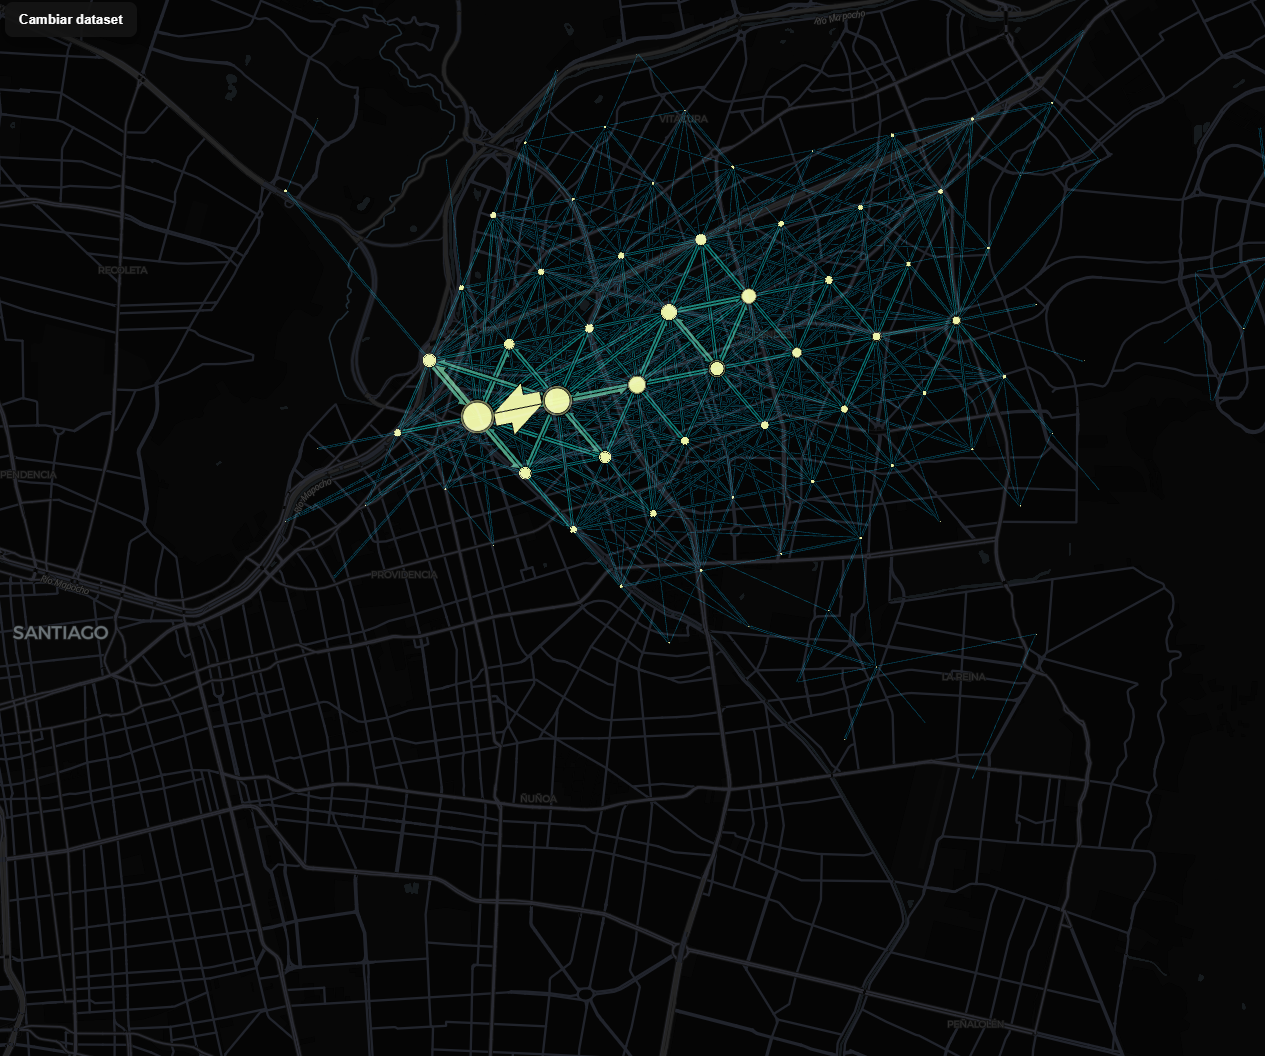

In [26]:
from IPython.display import Image
Image(REPO_ROOT / "images" / "f_scooters_baseline.png")

## Captura del flowmap - marzo 2019

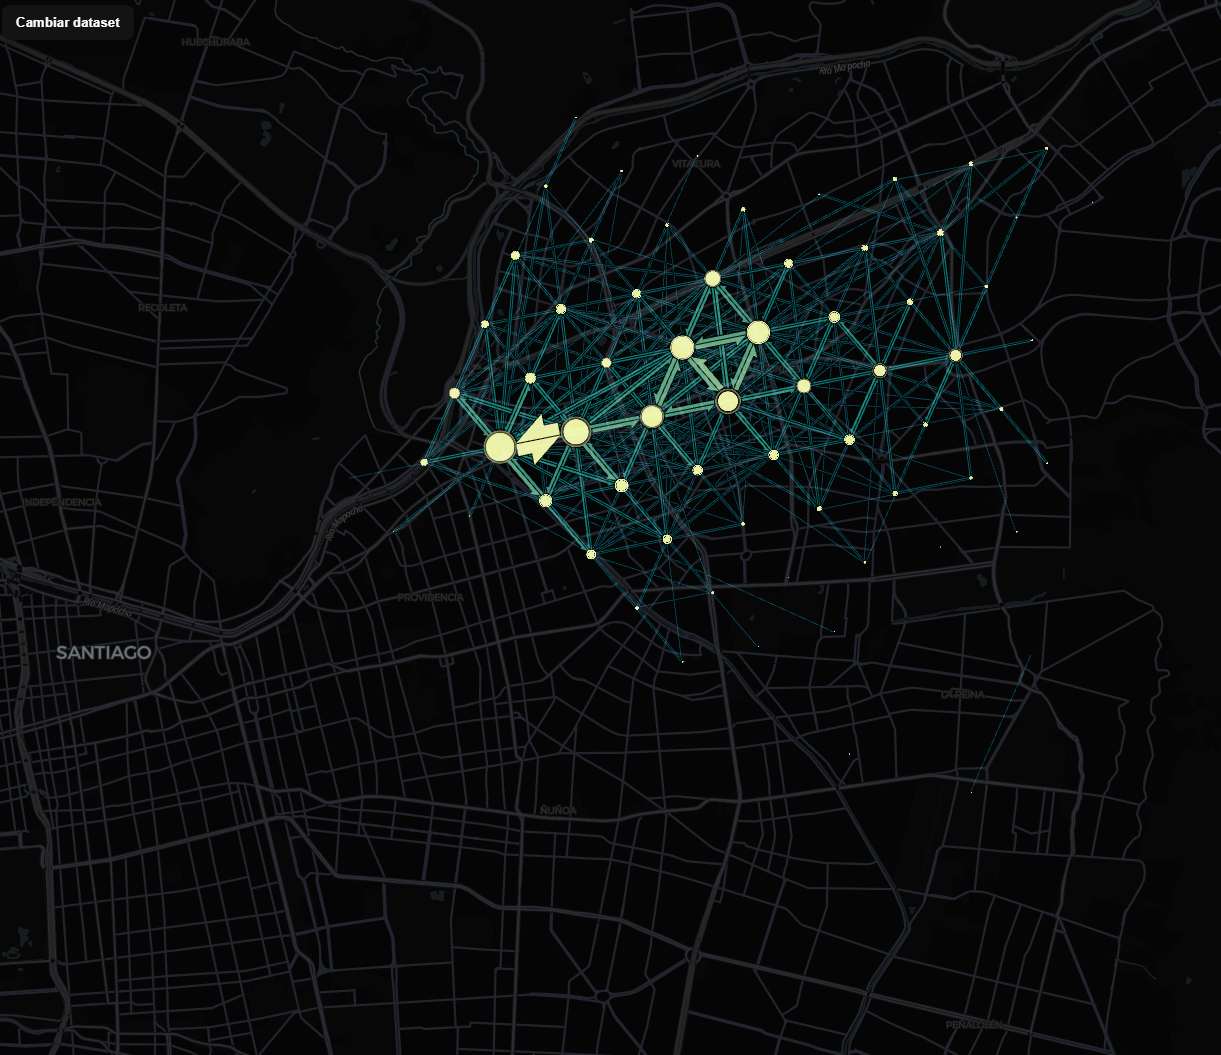

In [27]:
Image(REPO_ROOT / "images" / "f_scooters_march_2019.png")

## Captura del flowmap - tarde 18:00 a 22:59

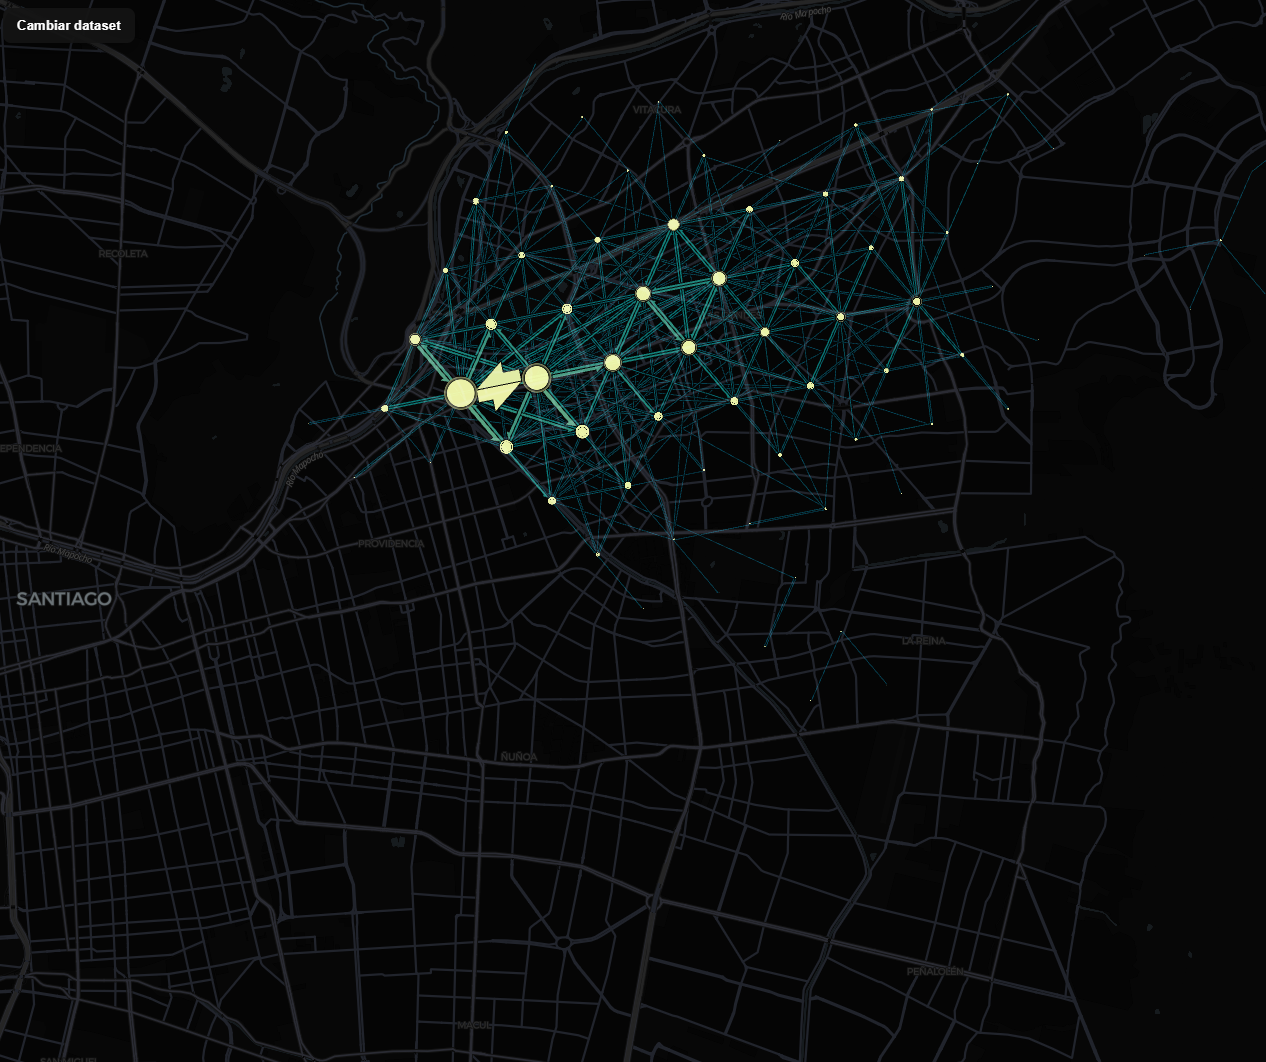

In [28]:
Image(REPO_ROOT / "images" / "f_scooters_evening_18_22.png")

## Cierre de la prueba

Esta prueba muestra que una fuente GeoJSON de trayectorias también puede integrarse de forma natural al pipeline del módulo cuando cada `Feature` ya representa un viaje suficientemente resumido.

El notebook deja cinco aportes principales:

1. un preprocess explícito desde una colección de trayectorias,
2. una validación formal del bloque de trips aplanados,
3. una limpieza estructural simple y reproducible,
4. tres flows persistidos: baseline, marzo 2019 y tarde 18:00-22:59,
5. y una comparación visual entre el baseline y dos contrastes temporales legibles.

Con ello, la prueba complementa las demás fuentes del proyecto y muestra que Pylondrina no solo absorbe tablas OD nativas o trips inferidos desde trazas, sino también trayectorias ya reportadas que pueden aplanarse de manera defendible a una representación tabular de viajes.